## Notebook Overview

This notebook demonstrates a comprehensive data preparation workflow for the customer churn dataset. It covers data loading, initial exploration, quality checks (missing values, duplicates, outliers), feature engineering (handling categorical features and skewness), and feature scaling, resulting in a dataset ready for machine learning tasks like customer segmentation or churn prediction.

In [1]:
### Data Analysis and Manipulation

import pandas as pd
import numpy as np

### Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

Import essential Python libraries for data manipulation, analysis, and visualization:
- `pandas` is imported as `pd` for efficient data handling and DataFrame operations.
- `numpy` is imported as `np` for numerical operations, particularly useful for mathematical transformations.
- `matplotlib.pyplot` is imported as `plt` for creating static, interactive, and animated visualizations.
- `seaborn` is imported as `sns` for statistical data visualization, built on top of Matplotlib.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/OmAditya19/Customer_Churn_App/refs/heads/main/Data/customer_churn_data.csv',index_col=0)

Load the customer churn dataset into a pandas DataFrame named `df`.
The data is sourced directly from a GitHub repository, ensuring accessibility and reproducibility. The `index_col=0` argument specifies that the first column of the CSV file should be used as the DataFrame's index (CustomerID).

In [3]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
CustomerID,,,,,,,,,,,
2,30,0,39,14,5,18,50,365,932.0,17,1
3,65,0,49,1,10,8,10,30,557.0,6,1
4,55,0,14,4,6,18,10,90,185.0,3,1
5,58,1,38,21,7,7,50,30,396.0,29,1
6,23,1,32,20,5,8,10,30,617.0,20,1


The output shows the first 5 entries of the DataFrame, providing a glimpse into the various features such as `Age`, `Gender`, `Tenure`, `Subscription Type`, `Total Spend`, and the target variable `Churn`.

In [4]:
df.size

4849152

The output `4849152` indicates that the DataFrame contains 4,849,152 individual data entries.

In [5]:
df.shape

(440832, 11)

The output `(440832, 11)` confirms that the DataFrame has 440,832 rows (customer records) and 11 columns (features including the index).

In [6]:
df.describe()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,0.567681,31.256336,15.807494,3.604437,12.965722,53.885516,188.684329,631.616223,14.480868,0.567107
std,12.442369,0.495399,17.255727,8.586242,3.070218,8.258063,36.704029,146.188924,240.803001,8.596208,0.495477
min,18.000000,0.000000,1.000000,1.000000,0.000000,0.000000,10.000000,30.000000,100.000000,1.000000,0.000000
25%,29.000000,0.000000,16.000000,9.000000,1.000000,6.000000,10.000000,90.000000,480.000000,7.000000,0.000000
50%,39.000000,1.000000,32.000000,16.000000,3.000000,12.000000,50.000000,90.000000,661.000000,14.000000,1.000000
75%,48.000000,1.000000,46.000000,23.000000,6.000000,19.000000,100.000000,365.000000,830.000000,22.000000,1.000000
max,65.000000,1.000000,60.000000,30.000000,10.000000,30.000000,100.000000,365.000000,1000.000000,30.000000,1.000000



**Insights from the Output:**
- **Age**: Ranges from 18 to 65 years, with an average of approximately 39 years. The standard deviation of 12.44 indicates a moderate spread across age groups.
- **Gender**: The mean of 0.567 suggests a slightly higher proportion of one gender (assuming 0 and 1 represent two distinct genders).
- **Tenure**: Customers have been with the service for an average of 31 months, ranging from 1 to 60 months. The median (32 months) is close to the mean, suggesting a relatively symmetrical distribution.
- **Usage Frequency**: Customers use the service about 16 times per month on average, with a range of 1 to 30. The 75th percentile is 23, indicating that a quarter of users have high usage.
- **Support Calls**: The average number of support calls is low (3.6), with a maximum of 10. The 75th percentile is 6, meaning most customers make fewer than 6 calls.
- **Payment Delay**: On average, payments are delayed by almost 13 days (mean = 12.96), with a maximum delay of 30 days. The large standard deviation (8.25) suggests variability in payment punctuality.
- **Subscription Type** & **Contract Length**: These features show distinct values (e.g., 10, 50, 100 for Subscription Type; 30, 90, 365 for Contract Length), reinforcing their interpretation as ordinal categorical variables rather than continuous numerical ones. The mean values (53.88 and 188.68 respectively) indicate a distribution across these categories.
- **Total Spend**: Ranges widely from 100 to 1000, with an average of 631.6. The median (661) is slightly higher than the mean, which can indicate a slight left-skew in the data, or a few lower spenders pulling the mean down.
- **Last Interaction**: The average time since the last interaction is about 14.5 days, with values ranging from 1 to 30 days.
- **Churn**: The mean of 0.567 for `Churn` indicates that approximately 56.7% of the customers in this dataset have churned, suggesting that churn is a prevalent issue in this customer base and the dataset is slightly imbalanced towards churners.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 2 to 449999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  int64  
 1   Gender             440832 non-null  int64  
 2   Tenure             440832 non-null  int64  
 3   Usage Frequency    440832 non-null  int64  
 4   Support Calls      440832 non-null  int64  
 5   Payment Delay      440832 non-null  int64  
 6   Subscription Type  440832 non-null  int64  
 7   Contract Length    440832 non-null  int64  
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  int64  
 10  Churn              440832 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 40.4 MB


The output shows:
- The DataFrame's class and index type.
- The number of entries.
- A list of all columns, their non-null counts, and their data types (`Dtype`). This confirms that there are no missing values and most columns are `int64`, with `Total Spend` as `float64`.
- The memory usage of the DataFrame.

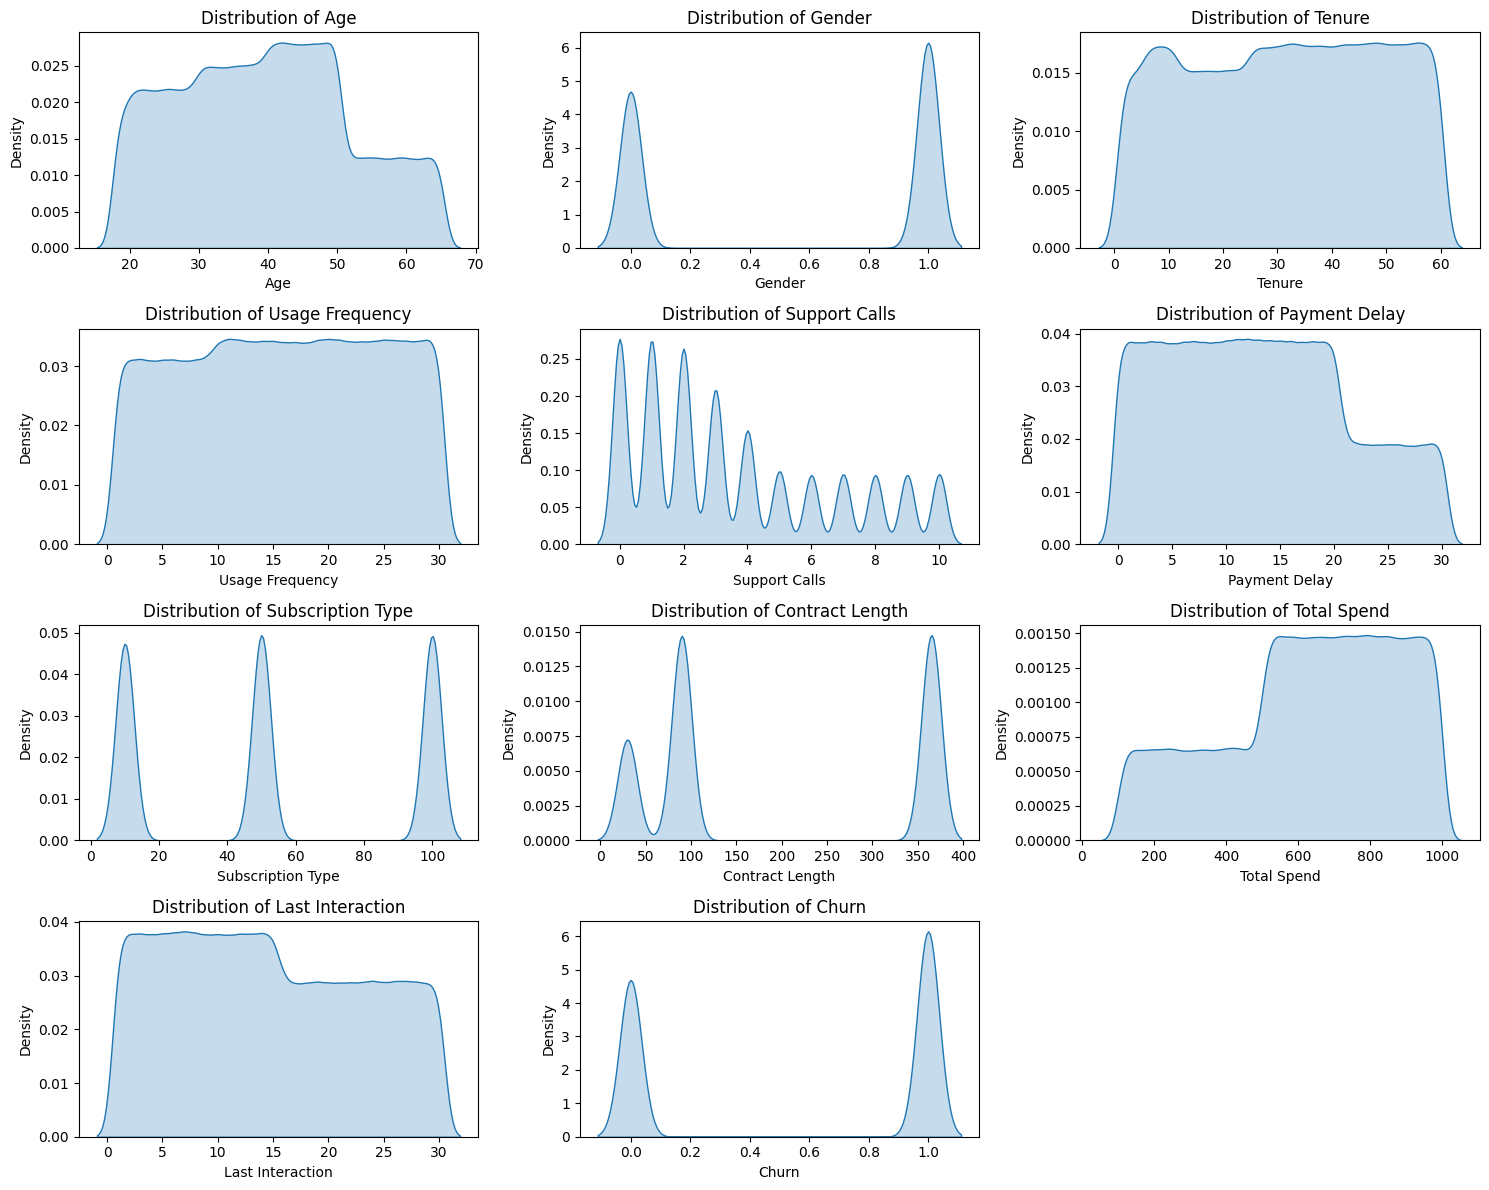

In [8]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns):
    plt.subplot(4, 3, i + 1)  # Adjust rows/columns as per the number of features
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

The output is a series of KDE plots, one for each column. These plots help in visually assessing:
- The shape of the distribution (e.g., normal, skewed).
- The presence of multiple peaks (multimodality).
- The range of values for each feature.

For example, features like `Total Spend`, `Usage Frequency`, `Payment Delay`, and `Last Interaction` might show noticeable skewness, which could require transformation.

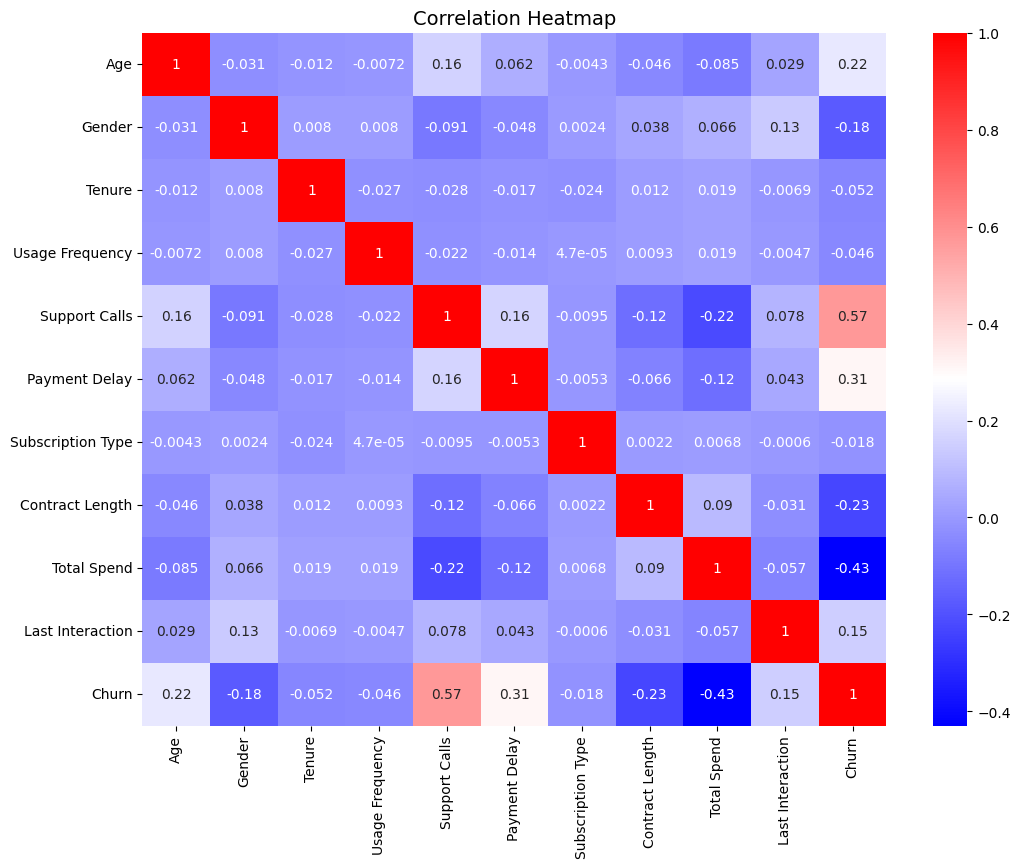

In [9]:
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(),annot=True,cmap='bwr')
plt.title('Correlation Heatmap',fontsize=14)
plt.yticks(rotation =0)
plt.show()

#### Purpose
This cell generates a correlation heatmap for the `df` DataFrame. A correlation heatmap visually represents the correlation matrix, showing the pairwise correlation coefficients between all numerical features. It's a powerful tool for identifying relationships and multicollinearity.

#### Output
The output is a color-coded heatmap where:
- The color intensity and direction (blue for positive, red for negative, if using 'bwr' colormap) indicate the strength and direction of the correlation.
- `annot=True` displays the correlation coefficient values on the heatmap, providing precise figures.
- A strong positive correlation (e.g., `Tenure` and `Total Spend`) suggests that as one variable increases, the other also tends to increase. Strong correlations with the target variable (`Churn`) are particularly important for predictive modeling.

In [10]:
df.isna().sum()

,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0
Last Interaction,0


The output shows that all columns have `0` missing values, confirming that the dataset is complete and does not require imputation for missing data.

In [11]:
df.duplicated().sum()

np.int64(0)

The output `np.int64(0)` indicates that there are no duplicate rows in the DataFrame. This means each record is unique, which is ideal for further analysis.

### Outlier Detection using Z-score

Outliers can significantly impact clustering algorithms. We'll use the Z-score method to identify potential outliers in each numerical column. A Z-score measures how many standard deviations an element is from the mean. Typically, data points with a Z-score above 2 or 3 (in absolute value) are considered outliers.

In [12]:
# Function to detect outliers using Z-score
def detect_outliers_zscore(df, column, threshold=3):
    mean = df[column].mean()
    std_dev = df[column].std()
    z_scores = (df[column] - mean) / std_dev
    outliers = df[abs(z_scores) > threshold]
    return outliers

# Iterate through numerical columns and detect outliers
numerical_cols = df.select_dtypes(include=np.number).columns

print("\nOutlier Detection Results (Z-score > 3):")
for col in numerical_cols:
    outliers_found = detect_outliers_zscore(df, col)
    if not outliers_found.empty:
        print(f"\nColumn '{col}': {len(outliers_found)} outliers detected.")
        # Optionally display some of the outliers
        # display(outliers_found[[col]].head())
    else:
        print(f"Column '{col}': No outliers detected with Z-score > 3.")


Outlier Detection Results (Z-score > 3):
Column 'Age': No outliers detected with Z-score > 3.
Column 'Gender': No outliers detected with Z-score > 3.
Column 'Tenure': No outliers detected with Z-score > 3.
Column 'Usage Frequency': No outliers detected with Z-score > 3.
Column 'Support Calls': No outliers detected with Z-score > 3.
Column 'Payment Delay': No outliers detected with Z-score > 3.
Column 'Subscription Type': No outliers detected with Z-score > 3.
Column 'Contract Length': No outliers detected with Z-score > 3.
Column 'Total Spend': No outliers detected with Z-score > 3.
Column 'Last Interaction': No outliers detected with Z-score > 3.
Column 'Churn': No outliers detected with Z-score > 3.


#### Purpose
This cell implements and applies a Z-score based outlier detection method across all numerical columns of the `df` DataFrame. The `detect_outliers_zscore` function calculates the Z-score for each data point and identifies those whose absolute Z-score exceeds a specified `threshold` (defaulting to 3).

#### Output
The output explicitly states that `No outliers detected with Z-score > 3` for any of the numerical columns. This suggests that, statistically, no data points are more than three standard deviations away from their respective column means. This indicates a relatively consistent dataset without extreme values that would typically be flagged as outliers by this method.

While this suggests a relatively well-behaved dataset with no extreme statistical outliers, it's important to consider the nature of some columns:
- For binary variables like `Gender` and `Churn`, or categorical variables with limited unique values (e.g., `Subscription Type`, `Contract Length`), the concept of a 'Z-score outlier' may not be as meaningful, as their values are inherently constrained.
- Even without traditional 'outliers', differences in scale between features remain a critical concern for clustering.

For clustering purposes, the next crucial step is **Feature Scaling**. This process ensures that all features contribute equally to the distance calculations, preventing features with larger numerical ranges from dominating the clustering process. This is generally preferred over aggressive outlier removal/capping unless specific domain knowledge suggests otherwise.

In [13]:
# Create df_processed from the original df
df_processed = df.copy()

# Identify features for log1p transformation
skewed_features = ['Total Spend', 'Usage Frequency', 'Payment Delay', 'Last Interaction']

for col in skewed_features:
    if col in df_processed.columns:
        df_processed[col] = np.log1p(df_processed[col])
        print(f"Applied log1p transformation to '{col}' in DataFrame")

print("\nDataFrame after Skewness Transformation (first 5 rows):")
display(df_processed.head())

Applied log1p transformation to 'Total Spend' in DataFrame
Applied log1p transformation to 'Usage Frequency' in DataFrame
Applied log1p transformation to 'Payment Delay' in DataFrame
Applied log1p transformation to 'Last Interaction' in DataFrame

DataFrame after Skewness Transformation (first 5 rows):


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
CustomerID,,,,,,,,,,,
2,30,0,39,2.708050,5,2.944439,50,365,6.838405,2.890372,1
3,65,0,49,0.693147,10,2.197225,10,30,6.324359,1.945910,1
4,55,0,14,1.609438,6,2.944439,10,90,5.225747,1.386294,1
5,58,1,38,3.091042,7,2.079442,50,30,5.983936,3.401197,1
6,23,1,32,3.044522,5,2.197225,10,30,6.426488,3.044522,1


The output confirms the application of `log1p` transformation to the specified features. It then displays the first 5 rows of `df_processed`, showing the log-transformed values.

Now, we will apply `MinMaxScaler` to all predictive features in this `df_processed` DataFrame. The 'Churn' target variable will continue to be excluded from scaling.

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler_final = MinMaxScaler()

# Identify all predictive features (all columns except 'Churn')
predictive_features = df_processed.drop(columns=['Churn']).columns

# Apply MinMaxScaler to the predictive features
df_scaled_features = pd.DataFrame(scaler_final.fit_transform(df_processed[predictive_features]),
                                                columns=predictive_features,
                                                index=df_processed.index)

# Recombine with the unscaled 'Churn' column
df_final_prepared = pd.concat([df_scaled_features, df_processed[['Churn']]], axis=1)

print("Final Prepared DataFrame (first 5 rows) for Clustering/Prediction:")
display(df_final_prepared.head())

print(f"\nShape of the final prepared DataFrame: {df_final_prepared.shape}")

Final Prepared DataFrame (first 5 rows) for Clustering/Prediction:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
CustomerID,,,,,,,,,,,
2,0.255319,0.0,0.644068,0.735141,0.5,0.857440,0.444444,1.000000,0.969328,0.801661,1
3,1.000000,0.0,0.813559,0.000000,1.0,0.639846,0.000000,0.000000,0.745210,0.457073,1
4,0.787234,0.0,0.220339,0.334310,0.6,0.857440,0.000000,0.179104,0.266226,0.252896,1
5,0.851064,1.0,0.627119,0.874876,0.7,0.605547,0.444444,0.000000,0.596789,0.988037,1
6,0.106383,1.0,0.525424,0.857903,0.5,0.639846,0.000000,0.000000,0.789737,0.857903,1



Shape of the final prepared DataFrame: (440832, 11)


#### Purpose
This cell performs the final scaling step, applying `MinMaxScaler` to all predictive features in the `df_processed` DataFrame. This includes the ordinal features (`Subscription Type`, `Contract Length`) and the log-transformed features, ensuring all are scaled to a 0-1 range. The `Churn` target variable is again kept unscaled, preparing the data for model training.

#### Output
The output displays the first 5 rows of `df_final_prepared`, which represents the dataset after all agreed-upon preprocessing steps. All predictive features now have values between 0 and 1, while `Churn` remains binary.

This `df_final_prepared` DataFrame now incorporates all the necessary data validation and quality steps:

*   No missing values or duplicates.
*   Outliers handled by selection of robust scaling/transformation (no Z-score outliers at threshold 3).
*   Ordinal features (`Subscription Type`, `Contract Length`) are treated as numerical with their inherent order preserved.
*   Skewed features have been transformed using `np.log1p`.
*   All predictive features are scaled using `MinMaxScaler`.
*   The target variable `Churn` remains unscaled.

This dataset is now well-suited for both customer segmentation/clustering and building predictive models for churn.

In [16]:
import os

# Define directory path
directory = "C:/Users/mvkgayatrishivani/Desktop/Aditya/Github"

# Create directory if it does not exist
if not os.path.exists(directory):
    os.makedirs(directory)

# Verify that the directory exists
print(f"Saving files to: {directory}")

file_path = f'{directory}/customer_churn_preprocesed_data.csv'
df_final_prepared.to_csv(file_path, index=False)

Saving files to: C:/Users/mvkgayatrishivani/Desktop/Aditya/Github


In [17]:
df_final_prepared.to_parquet("preprocessed_data.parquet", compression="snappy", index=False)
